# Data Cleaning and Exploratory Analysis

This notebook prepares the raw Waze user churn dataset for analysis and modeling.

The main goal is to understand the structure of the data, clean the churn label, check for missing or duplicate records, create a few behavior-based features, and identify the first patterns tied to churn.

## 1. Load Raw Data

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the raw dataset exactly as downloaded.
df = pd.read_csv("/content/waze_dataset.csv")

df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [22]:
# Quick shape and type check before making any changes.
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 14999
Columns: 13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5

## 2. Clean Column Names

The raw columns are already readable, but I’m standardizing them to lowercase snake case so the rest of the notebook is easier to work with.

In [23]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.columns.tolist()

['id',
 'label',
 'sessions',
 'drives',
 'total_sessions',
 'n_days_after_onboarding',
 'total_navigations_fav1',
 'total_navigations_fav2',
 'driven_km_drives',
 'duration_minutes_drives',
 'activity_days',
 'driving_days',
 'device']

## 3. Check Missing Values and Duplicates

Before analyzing churn, I want to see whether any fields are missing values and whether each user ID appears only once.

In [24]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values("missing_count", ascending=False)

missing_summary

,missing_count,missing_percent
label,700,4.67
id,0,0.00
sessions,0,0.00
drives,0,0.00
total_sessions,0,0.00
n_days_after_onboarding,0,0.00
total_navigations_fav1,0,0.00
total_navigations_fav2,0,0.00
driven_km_drives,0,0.00
duration_minutes_drives,0,0.00


In [25]:
# Check whether user IDs or full rows are duplicated.
print("Duplicate IDs:", df["id"].duplicated().sum())
print("Duplicate rows:", df.duplicated().sum())

Duplicate IDs: 0
Duplicate rows: 0


## 4. Prepare the Churn Target

The label field is the churn outcome. Some records are missing the label, so I’m keeping those out of the modeling dataset instead of guessing the outcome.

In [26]:
df["label"].value_counts(dropna=False)

,count
label,
retained,11763
churned,2536
NaN,700


In [27]:
# Convert the text label into a numeric churn flag.
df["churned"] = df["label"].map({
    "churned": 1,
    "retained": 0
})

df[["label", "churned"]].drop_duplicates()

,label,churned
0,retained,0.0
9,churned,1.0
77,NaN,NaN


In [28]:
# Keep only records where the churn outcome is known.
df_model = df[df["churned"].notna()].copy()

print("Original rows:", df.shape[0])
print("Rows with known churn label:", df_model.shape[0])
print("Rows removed due to missing label:", df.shape[0] - df_model.shape[0])

Original rows: 14999
Rows with known churn label: 14299
Rows removed due to missing label: 700


## 5. Overall Churn Rate

This gives the baseline churn rate before looking at behavior patterns or segments.

In [29]:
churn_rate = df_model["churned"].mean()

print(f"Overall churn rate: {churn_rate:.2%}")

df_model["churned"].value_counts(normalize=True).rename("proportion").to_frame()

Overall churn rate: 17.74%


,proportion
churned,
0.0,0.822645
1.0,0.177355


## 6. Compare User Behavior by Churn Status

This first comparison looks at whether churned users behave differently from retained users across sessions, drives, navigation activity, account age, and active days.

In [30]:
numeric_cols = [
    "sessions",
    "drives",
    "total_sessions",
    "n_days_after_onboarding",
    "total_navigations_fav1",
    "total_navigations_fav2",
    "driven_km_drives",
    "duration_minutes_drives",
    "activity_days",
    "driving_days"
]

summary_by_churn = df_model.groupby("churned")[numeric_cols].mean().T
summary_by_churn.columns = ["retained_avg", "churned_avg"]
summary_by_churn["difference_churned_minus_retained"] = (
    summary_by_churn["churned_avg"] - summary_by_churn["retained_avg"]
)

summary_by_churn.round(2)

,retained_avg,churned_avg,difference_churned_minus_retained
sessions,79.20,87.24,8.04
drives,66.08,72.73,6.66
total_sessions,187.96,196.89,8.93
n_days_after_onboarding,1812.36,1471.03,-341.33
total_navigations_fav1,117.94,139.41,21.48
total_navigations_fav2,29.22,31.60,2.38
driven_km_drives,4022.25,4147.17,124.93
duration_minutes_drives,1840.21,1975.46,135.25
activity_days,16.82,9.64,-7.17
driving_days,13.25,7.22,-6.03


## 7. Engineer Behavior Features

The raw totals are useful, but churn may be more related to consistency and intensity than volume alone. These features help compare how often users are active, how concentrated their usage is, and how much they rely on saved navigation behavior.

In [31]:
df_model["sessions_per_activity_day"] = (
    df_model["sessions"] / df_model["activity_days"].replace(0, np.nan)
)

df_model["drives_per_driving_day"] = (
    df_model["drives"] / df_model["driving_days"].replace(0, np.nan)
)

df_model["km_per_drive"] = (
    df_model["driven_km_drives"] / df_model["drives"].replace(0, np.nan)
)

df_model["minutes_per_drive"] = (
    df_model["duration_minutes_drives"] / df_model["drives"].replace(0, np.nan)
)

df_model["fav_navigation_total"] = (
    df_model["total_navigations_fav1"] + df_model["total_navigations_fav2"]
)

df_model["activity_rate"] = (
    df_model["activity_days"] / df_model["n_days_after_onboarding"].replace(0, np.nan)
)

df_model["driving_rate"] = (
    df_model["driving_days"] / df_model["n_days_after_onboarding"].replace(0, np.nan)
)

# Division can create inf values when a denominator is zero, so I clean those before summarizing.
df_model = df_model.replace([np.inf, -np.inf], np.nan)

df_model.head()

,id,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,...,driving_days,device,churned,sessions_per_activity_day,drives_per_driving_day,km_per_drive,minutes_per_drive,fav_navigation_total,activity_rate,driving_rate
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,...,19,Android,0.0,10.107143,11.894737,11.632058,8.786615,208,0.012302,0.008348
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,...,11,iPhone,0.0,10.230769,9.727273,128.186173,29.537130,83,0.010612,0.008980
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,...,8,Android,0.0,8.142857,11.875000,32.201567,16.955115,0,0.005281,0.003018
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,...,3,iPhone,0.0,7.000000,13.333333,22.839778,14.679914,329,0.466667,0.200000
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,...,18,Android,0.0,3.111111,3.777778,58.091206,17.934646,171,0.017286,0.011524


In [32]:
engineered_cols = [
    "sessions_per_activity_day",
    "drives_per_driving_day",
    "km_per_drive",
    "minutes_per_drive",
    "fav_navigation_total",
    "activity_rate",
    "driving_rate"
]

engineered_summary = df_model.groupby("churned")[engineered_cols].mean().T
engineered_summary.columns = ["retained_avg", "churned_avg"]
engineered_summary["difference_churned_minus_retained"] = (
    engineered_summary["churned_avg"] - engineered_summary["retained_avg"]
)

engineered_summary.round(4)

,retained_avg,churned_avg,difference_churned_minus_retained
sessions_per_activity_day,8.5038,19.6142,11.1104
drives_per_driving_day,8.5098,18.0892,9.5794
km_per_drive,234.0880,233.2435,-0.8445
minutes_per_drive,108.6094,112.1138,3.5044
fav_navigation_total,147.1546,171.0114,23.8569
activity_rate,0.0283,0.0254,-0.0029
driving_rate,0.0223,0.0197,-0.0026


## 8. Churn by Device

Device is worth checking, but I do not want to assume platform matters unless the data shows a real difference.

In [33]:
device_churn = (
    df_model.groupby("device")
    .agg(
        users=("id", "count"),
        churned_users=("churned", "sum"),
        churn_rate=("churned", "mean"),
        avg_sessions=("sessions", "mean"),
        avg_activity_days=("activity_days", "mean"),
        avg_driving_days=("driving_days", "mean")
    )
    .reset_index()
)

device_churn["churn_rate"] = device_churn["churn_rate"].round(4)

device_churn

,device,users,churned_users,churn_rate,avg_sessions,avg_activity_days,avg_driving_days
0,Android,5074,891.0,0.1756,79.049074,15.668900,12.223295
1,iPhone,9225,1645.0,0.1783,81.489973,15.476314,12.160108


## 9. Churn by Tenure Group

Account age is a useful way to separate newer users from more established users. I’m using quartiles so each tenure group is roughly the same size.

In [34]:
df_model["tenure_group"] = pd.qcut(
    df_model["n_days_after_onboarding"],
    q=4,
    labels=["newest_users", "early_mid_tenure", "late_mid_tenure", "longest_tenure"]
)

tenure_churn = (
    df_model.groupby("tenure_group", observed=True)
    .agg(
        users=("id", "count"),
        churn_rate=("churned", "mean"),
        avg_activity_days=("activity_days", "mean"),
        avg_driving_days=("driving_days", "mean"),
        avg_sessions=("sessions", "mean")
    )
    .reset_index()
)

tenure_churn["churn_rate"] = tenure_churn["churn_rate"].round(4)

tenure_churn

,tenure_group,users,churn_rate,avg_activity_days,avg_driving_days,avg_sessions
0,newest_users,3575,0.2470,15.662098,12.242517,80.543217
1,early_mid_tenure,3577,0.1940,15.702544,12.330445,78.770198
2,late_mid_tenure,3572,0.1487,15.338186,12.014278,82.073348
3,longest_tenure,3575,0.1197,15.475524,12.142657,81.110769


## 10. Churn by Activity Group

This view groups users by activity days and compares churn across those groups.

In [35]:
df_model["activity_group"] = pd.qcut(
    df_model["activity_days"],
    q=4,
    labels=["lowest_activity", "low_mid_activity", "high_mid_activity", "highest_activity"]
)

activity_churn = (
    df_model.groupby("activity_group", observed=True)
    .agg(
        users=("id", "count"),
        churn_rate=("churned", "mean"),
        avg_sessions=("sessions", "mean"),
        avg_drives=("drives", "mean"),
        avg_tenure_days=("n_days_after_onboarding", "mean")
    )
    .reset_index()
)

activity_churn["churn_rate"] = activity_churn["churn_rate"].round(4)

activity_churn

,activity_group,users,churn_rate,avg_sessions,avg_drives,avg_tenure_days
0,lowest_activity,3960,0.3472,78.249747,65.344697,1768.961111
1,low_mid_activity,3560,0.1848,80.430056,67.087079,1738.807584
2,high_mid_activity,3249,0.0994,81.317944,67.807018,1741.555863
3,highest_activity,3530,0.0510,82.843626,69.062606,1755.171105


## 11. Quick Visual Checks

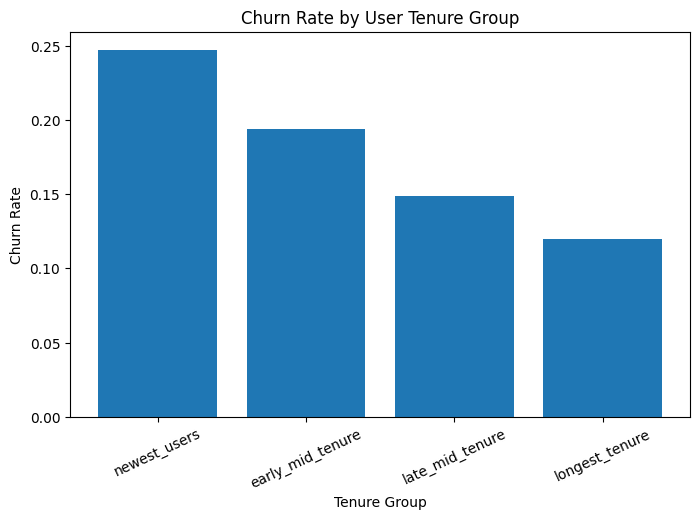

In [36]:
plt.figure(figsize=(8, 5))
plt.bar(tenure_churn["tenure_group"].astype(str), tenure_churn["churn_rate"])
plt.title("Churn Rate by User Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate")
plt.xticks(rotation=25)
plt.show()

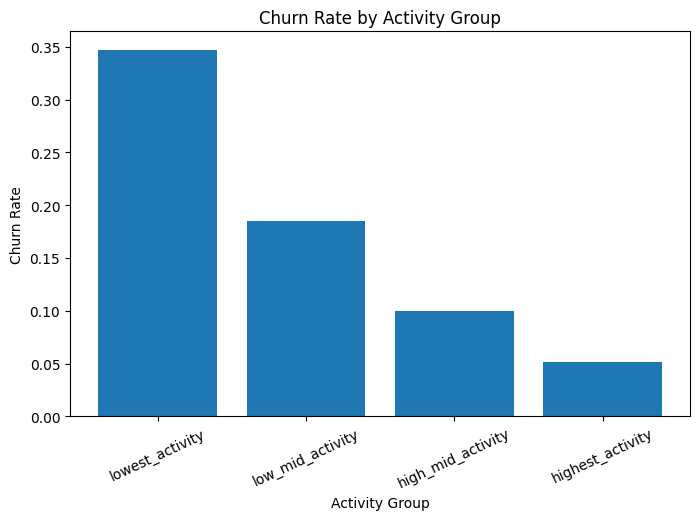

In [37]:
plt.figure(figsize=(8, 5))
plt.bar(activity_churn["activity_group"].astype(str), activity_churn["churn_rate"])
plt.title("Churn Rate by Activity Group")
plt.xlabel("Activity Group")
plt.ylabel("Churn Rate")
plt.xticks(rotation=25)
plt.show()

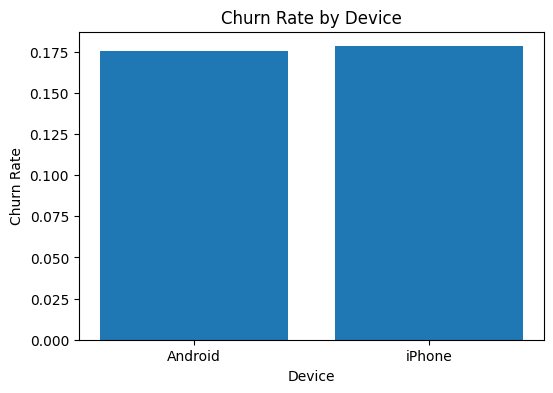

In [38]:
plt.figure(figsize=(6, 4))
plt.bar(device_churn["device"], device_churn["churn_rate"])
plt.title("Churn Rate by Device")
plt.xlabel("Device")
plt.ylabel("Churn Rate")
plt.show()

## 12. Early Findings

The strongest churn patterns are tied to consistency and account age.

Churned users are not simply inactive users. On average, they have more sessions, more drives, more navigation activity, and slightly more driving time. The bigger difference is that they are active across fewer days and have lower account tenure.

Device type does not show much separation. Android and iPhone churn rates are nearly the same.

The clearest pattern is activity consistency. Users in the lowest activity group churn at a much higher rate than users in the highest activity group. Tenure shows a similar pattern, with newer users churning more often than longer-tenured users.

For the next notebook, I’ll use these behavior and consistency features to test whether churn risk can be predicted well enough to support retention prioritization.

## 13. Export Cleaned Dataset

In [39]:
df_model.to_csv("waze_churn_cleaned.csv", index=False)

print("Exported cleaned file: waze_churn_cleaned.csv")

Exported cleaned file: waze_churn_cleaned.csv
